# KBO 월별 타격 데이터 신뢰도 보정 및 SQLite 분석 파이프라인

구자욱 선수의 2015–2025년 월별 타격 기록을 정제하고, 타수가 적은 달의 타율이 과도하게 흔들리는 문제를 **베타-이항 축소 추정(Beta-Binomial shrinkage)**으로 보정합니다. 이후 분석 결과를 CSV와 SQLite에 적재하고 SQL로 재조회합니다.

## 핵심 질문

- `4타수 2안타(0.500)`와 `100타수 30안타(0.300)`를 같은 신뢰도로 비교해도 되는가?
- 타수가 적은 월의 관측 타율을 어떤 방식으로 보수적으로 해석할 수 있는가?
- 정제·모델링 결과를 재사용 가능한 데이터베이스로 연결할 수 있는가?

> 이 프로젝트의 `adjusted_avg`는 미래 타율 예측값이 아니라, 표본 크기를 반영한 **기술적 추정치**입니다.

## 1. 환경 설정

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import beta

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "kjw.xlsx"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
DB_PATH = OUTPUT_DIR / "kbo_monthly.db"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Data file exists: {DATA_PATH.exists()}")

Project directory: /mnt/data/KBO_portfolio_revised
Data file exists: True


## 2. 원본 데이터 불러오기

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "kjw.xlsx를 노트북과 같은 폴더에 두고 다시 실행하세요. "
        f"현재 확인 경로: {DATA_PATH}"
    )

raw_df = pd.read_excel(DATA_PATH)
print(f"Raw shape: {raw_df.shape}")
display(raw_df.head())

Raw shape: (77, 29)


,Unnamed: 0,월,PA,ePA,AB,R,H,2B,3B,HR,TB,RBI,SB,CS,BB,HP,IB,SO,GDP,SH,SF,AVG,OBP,SLG,OPS,NP,avLI,RE24,WPA
0,"2,025.0000",3월,36,35,31,7,8,2,0,2,16,11,0,0,4,0,1,3,0,0,1,0.2580,0.3330,0.5160,0.8490,114,0.9800,6.6300,0.2350
1,NaN,4월,101,99,85,20,22,5,0,5,42,11,0,0,14,0,2,22,0,1,1,0.2590,0.3600,0.4940,0.8540,429,1.0500,0.8600,-0.1290
2,NaN,5월,102,102,89,14,21,7,0,2,34,14,0,1,10,1,0,11,5,0,2,0.2360,0.3140,0.3820,0.6960,434,1.1000,-1.1000,-0.1040
3,NaN,6월,94,94,85,14,28,6,0,3,43,16,0,0,6,2,1,20,0,0,1,0.3290,0.3830,0.5060,0.8890,383,1.0600,6.2300,1.0220
4,NaN,7월,83,82,71,17,33,10,0,1,46,8,0,0,8,2,1,11,2,0,2,0.4650,0.5180,0.6480,1.1660,311,1.0800,6.7400,0.8360


## 3. 데이터 정제 및 표준화

원본 첫 번째 열에는 연도가 첫 월에만 기록되어 있으므로 아래 행으로 채웁니다. 분석 및 SQL 사용성을 높이기 위해 핵심 변수명을 영문 소문자로 표준화합니다.

In [3]:
df = raw_df.copy()

# 첫 번째 열은 파일에서 이름이 비어 있으므로 연도 열로 처리합니다.
df = df.rename(columns={df.columns[0]: "year"})
df["year"] = pd.to_numeric(df["year"], errors="coerce").ffill().astype(int)
df["month"] = (
    df["월"].astype(str).str.extract(r"(\d+)", expand=False).astype(int)
)

column_map = {
    "월": "month_label",
    "PA": "plate_appearances",
    "AB": "at_bats",
    "H": "hits",
    "HR": "home_runs",
    "BB": "walks",
    "SO": "strikeouts",
    "AVG": "avg_reported",
    "OBP": "on_base_percentage",
    "SLG": "slugging_percentage",
    "OPS": "on_base_plus_slugging",
}
df = df.rename(columns=column_map)

analysis_columns = [
    "year", "month", "month_label", "plate_appearances", "at_bats", "hits",
    "home_runs", "walks", "strikeouts", "avg_reported",
    "on_base_percentage", "slugging_percentage", "on_base_plus_slugging",
]
analysis_df = df[analysis_columns].copy()

numeric_columns = [
    "plate_appearances", "at_bats", "hits", "home_runs", "walks", "strikeouts",
    "avg_reported", "on_base_percentage", "slugging_percentage",
    "on_base_plus_slugging",
]
analysis_df[numeric_columns] = analysis_df[numeric_columns].apply(
    pd.to_numeric, errors="coerce"
)

analysis_df["period"] = pd.to_datetime(
    dict(year=analysis_df["year"], month=analysis_df["month"], day=1)
)
analysis_df = analysis_df.sort_values(["year", "month"]).reset_index(drop=True)

display(analysis_df.head())

,year,month,month_label,plate_appearances,at_bats,hits,home_runs,walks,strikeouts,avg_reported,on_base_percentage,slugging_percentage,on_base_plus_slugging,period
0,2015,3,3월,13,12,3,0,0,0,0.2500,0.3080,0.4170,0.7250,2015-03-01
1,2015,4,4월,81,69,18,3,11,18,0.2610,0.3580,0.4490,0.8070,2015-04-01
2,2015,5,5월,90,84,26,3,5,19,0.3100,0.3560,0.5240,0.8800,2015-05-01
3,2015,6,6월,57,50,23,3,7,7,0.4600,0.5260,0.8000,1.3260,2015-06-01
4,2015,7,7월,100,85,36,0,12,11,0.4240,0.4900,0.5290,1.0190,2015-07-01


## 4. 데이터 품질 검증

In [4]:
analysis_df["avg_calculated"] = analysis_df["hits"] / analysis_df["at_bats"]
analysis_df["avg_rounding_gap"] = (
    analysis_df["avg_reported"] - analysis_df["avg_calculated"]
).abs()

quality_report = pd.DataFrame(
    {
        "metric": [
            "source_rows",
            "source_columns",
            "cleaned_rows",
            "missing_cells",
            "duplicate_year_month",
            "invalid_hits_greater_than_at_bats",
            "maximum_reported_vs_calculated_avg_gap",
        ],
        "value": [
            raw_df.shape[0],
            raw_df.shape[1],
            analysis_df.shape[0],
            int(analysis_df.isna().sum().sum()),
            int(analysis_df.duplicated(["year", "month"]).sum()),
            int((analysis_df["hits"] > analysis_df["at_bats"]).sum()),
            analysis_df["avg_rounding_gap"].max(),
        ],
    }
)
display(quality_report)

assert analysis_df.duplicated(["year", "month"]).sum() == 0
assert (analysis_df["hits"] <= analysis_df["at_bats"]).all()
assert analysis_df["avg_rounding_gap"].max() <= 0.001

,metric,value
0,source_rows,77.0000
1,source_columns,29.0000
2,cleaned_rows,77.0000
3,missing_cells,0.0000
4,duplicate_year_month,0.0000
5,invalid_hits_greater_than_at_bats,0.0000
6,maximum_reported_vs_calculated_avg_gap,0.0005


검증 결과, 연도·월 중복이나 `안타 > 타수`와 같은 구조적 오류는 없었습니다. 제공된 타율과 `안타 ÷ 타수`의 차이는 반올림 범위 안에 있으므로, 이후 계산에는 더 정밀한 `avg_calculated`를 사용합니다.

## 5. 표본 크기를 반영한 타율 보정

관측 타율은 타수가 적을수록 크게 흔들립니다. 이를 완화하기 위해 커리어 가중 타율을 사전 평균으로 두고, **50타수에 해당하는 사전 강도(prior strength)**를 부여합니다.

\[
\text{Adjusted AVG}
= \frac{H + k p_0}{AB + k}
\]

- \(H\): 해당 월 안타 수
- \(AB\): 해당 월 타수
- \(p_0\): 전체 기록의 가중 커리어 타율
- \(k\): 사전 강도, 본 분석에서는 50

`at_bats / (at_bats + 50)`을 신뢰도 가중치로 볼 수 있습니다. 타수가 많을수록 관측 타율을 더 많이 반영하고, 타수가 적을수록 커리어 평균 쪽으로 더 크게 조정합니다.

In [5]:
PRIOR_STRENGTH = 50.0
career_avg = analysis_df["hits"].sum() / analysis_df["at_bats"].sum()
alpha_prior = career_avg * PRIOR_STRENGTH
beta_prior = (1 - career_avg) * PRIOR_STRENGTH

analysis_df["posterior_alpha"] = analysis_df["hits"] + alpha_prior
analysis_df["posterior_beta"] = (
    analysis_df["at_bats"] - analysis_df["hits"] + beta_prior
)
analysis_df["adjusted_avg"] = (
    analysis_df["posterior_alpha"]
    / (analysis_df["posterior_alpha"] + analysis_df["posterior_beta"])
)
analysis_df["credible_interval_lower"] = beta.ppf(
    0.025,
    analysis_df["posterior_alpha"],
    analysis_df["posterior_beta"],
)
analysis_df["credible_interval_upper"] = beta.ppf(
    0.975,
    analysis_df["posterior_alpha"],
    analysis_df["posterior_beta"],
)
analysis_df["reliability_weight"] = (
    analysis_df["at_bats"] / (analysis_df["at_bats"] + PRIOR_STRENGTH)
)
analysis_df["adjustment"] = (
    analysis_df["adjusted_avg"] - analysis_df["avg_calculated"]
)
analysis_df["absolute_adjustment"] = analysis_df["adjustment"].abs()

model_summary = pd.DataFrame(
    {
        "metric": [
            "records",
            "career_hits",
            "career_at_bats",
            "weighted_career_avg",
            "prior_strength_at_bats",
            "mean_absolute_adjustment",
        ],
        "value": [
            len(analysis_df),
            int(analysis_df["hits"].sum()),
            int(analysis_df["at_bats"].sum()),
            career_avg,
            PRIOR_STRENGTH,
            analysis_df["absolute_adjustment"].mean(),
        ],
    }
)
display(model_summary)

,metric,value
0,records,77.0000
1,career_hits,"1,656.0000"
2,career_at_bats,"5,210.0000"
3,weighted_career_avg,0.3179
4,prior_strength_at_bats,50.0000
5,mean_absolute_adjustment,0.0307


In [6]:
top_adjustments = (
    analysis_df[
        [
            "year", "month", "at_bats", "hits", "avg_calculated",
            "adjusted_avg", "adjustment", "reliability_weight",
            "credible_interval_lower", "credible_interval_upper",
        ]
    ]
    .sort_values("adjustment", key=lambda s: s.abs(), ascending=False)
    .head(10)
)
display(top_adjustments)

,year,month,at_bats,hits,avg_calculated,adjusted_avg,adjustment,reliability_weight,credible_interval_lower,credible_interval_upper
13,2017,3,4,2,0.5000,0.3313,-0.1687,0.0741,0.2135,0.4611
20,2017,10,7,1,0.1429,0.2964,0.1535,0.1228,0.1862,0.4201
12,2016,10,14,2,0.1429,0.2796,0.1367,0.2188,0.1775,0.3947
45,2021,7,27,4,0.1481,0.2583,0.1102,0.3506,0.1675,0.3610
28,2018,10,16,7,0.4375,0.3469,-0.0906,0.2424,0.2377,0.4648
69,2024,9,58,29,0.5000,0.4157,-0.0843,0.5370,0.3248,0.5095
21,2018,3,31,6,0.1935,0.2703,0.0767,0.3827,0.1799,0.3714
63,2024,3,30,6,0.2000,0.2737,0.0737,0.3750,0.1823,0.3757
3,2015,6,50,23,0.4600,0.3889,-0.0711,0.5000,0.2962,0.4859
33,2019,7,27,6,0.2222,0.2843,0.0621,0.3506,0.1899,0.3893


## 6. 사전 강도 민감도 점검

In [7]:
def adjusted_average(at_bats, hits, prior_strength, prior_mean):
    return (hits + prior_strength * prior_mean) / (at_bats + prior_strength)

sensitivity_rows = []
for strength in [25, 50, 100]:
    adjusted = adjusted_average(
        analysis_df["at_bats"],
        analysis_df["hits"],
        strength,
        career_avg,
    )
    change = (adjusted - analysis_df["avg_calculated"]).abs()
    sensitivity_rows.append(
        {
            "prior_strength": strength,
            "mean_absolute_adjustment": change.mean(),
            "maximum_absolute_adjustment": change.max(),
        }
    )

sensitivity_summary = pd.DataFrame(sensitivity_rows)
display(sensitivity_summary)

,prior_strength,mean_absolute_adjustment,maximum_absolute_adjustment
0,25,0.0221,0.1570
1,50,0.0307,0.1687
2,100,0.0394,0.1751


사전 강도가 커질수록 커리어 평균 쪽으로 더 강하게 조정됩니다. `50`은 해석이 쉬운 기준값으로 선택했으며, 최적값으로 검증된 것은 아닙니다. 향후 연구에서는 이후 월 성적 예측 오차를 기준으로 값을 선택할 수 있습니다.

## 7. 시각화

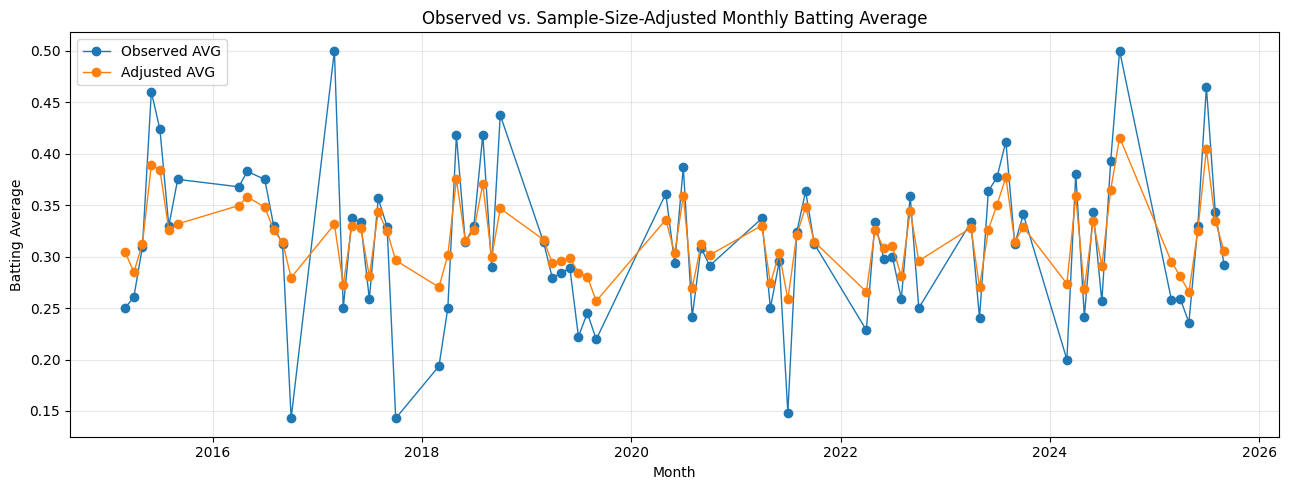

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    analysis_df["period"],
    analysis_df["avg_calculated"],
    marker="o",
    linewidth=1,
    label="Observed AVG",
)
ax.plot(
    analysis_df["period"],
    analysis_df["adjusted_avg"],
    marker="o",
    linewidth=1,
    label="Adjusted AVG",
)
ax.set_title("Observed vs. Sample-Size-Adjusted Monthly Batting Average")
ax.set_xlabel("Month")
ax.set_ylabel("Batting Average")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "observed_vs_adjusted.png", dpi=160, bbox_inches="tight")
plt.show()

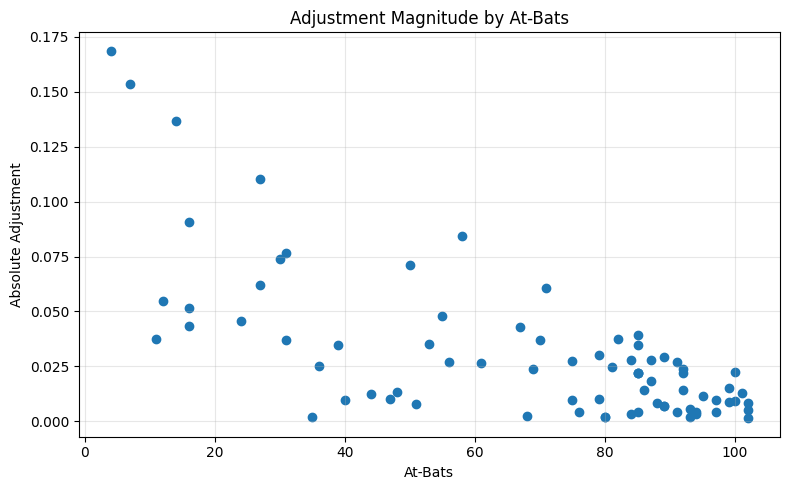

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(analysis_df["at_bats"], analysis_df["absolute_adjustment"])
ax.set_title("Adjustment Magnitude by At-Bats")
ax.set_xlabel("At-Bats")
ax.set_ylabel("Absolute Adjustment")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "adjustment_by_at_bats.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. CSV·SQLite 적재

전처리와 보정이 끝난 `analysis_df`를 저장합니다. 원본 Excel을 다시 읽어 DB에 넣지 않고, **실제 분석에 사용한 최종 데이터**를 적재합니다.

In [10]:
processed_columns = [
    "year", "month", "month_label", "period", "plate_appearances",
    "at_bats", "hits", "home_runs", "walks", "strikeouts",
    "avg_reported", "avg_calculated", "adjusted_avg",
    "credible_interval_lower", "credible_interval_upper",
    "reliability_weight", "adjustment", "absolute_adjustment",
    "on_base_percentage", "slugging_percentage", "on_base_plus_slugging",
]
processed_df = analysis_df[processed_columns].copy()
processed_df.to_csv(OUTPUT_DIR / "kbo_monthly_processed.csv", index=False)

db_df = processed_df.copy()
db_df["period"] = db_df["period"].dt.strftime("%Y-%m-%d")

with sqlite3.connect(DB_PATH) as connection:
    db_df.to_sql(
        "monthly_batting",
        connection,
        if_exists="replace",
        index=False,
    )
    connection.execute(
        "CREATE INDEX IF NOT EXISTS idx_monthly_batting_year_month "
        "ON monthly_batting(year, month)"
    )

print(f"CSV saved: {OUTPUT_DIR / 'kbo_monthly_processed.csv'}")
print(f"SQLite saved: {DB_PATH}")

CSV saved: /mnt/data/KBO_portfolio_revised/outputs/kbo_monthly_processed.csv
SQLite saved: /mnt/data/KBO_portfolio_revised/outputs/kbo_monthly.db


## 9. SQL 분석

월별 통산 타율은 월별 타율을 그대로 평균내지 않고 `SUM(hits) / SUM(at_bats)`로 계산합니다. 각 월의 표본 크기를 반영한 가중 계산입니다.

In [11]:
monthly_summary_query = """
SELECT
    month,
    COUNT(*) AS monthly_records,
    SUM(hits) AS total_hits,
    SUM(at_bats) AS total_at_bats,
    ROUND(1.0 * SUM(hits) / SUM(at_bats), 3) AS weighted_observed_avg,
    ROUND(AVG(adjusted_avg), 3) AS mean_adjusted_avg
FROM monthly_batting
GROUP BY month
ORDER BY month;
"""

largest_adjustments_query = """
SELECT
    year,
    month,
    at_bats,
    hits,
    ROUND(avg_calculated, 3) AS observed_avg,
    ROUND(adjusted_avg, 3) AS adjusted_avg,
    ROUND(adjustment, 3) AS adjustment,
    ROUND(reliability_weight, 3) AS reliability_weight
FROM monthly_batting
ORDER BY ABS(adjustment) DESC
LIMIT 10;
"""

annual_summary_query = """
SELECT
    year,
    SUM(hits) AS total_hits,
    SUM(at_bats) AS total_at_bats,
    ROUND(1.0 * SUM(hits) / SUM(at_bats), 3) AS weighted_avg,
    ROUND(AVG(on_base_plus_slugging), 3) AS mean_monthly_ops
FROM monthly_batting
GROUP BY year
ORDER BY year;
"""

with sqlite3.connect(DB_PATH) as connection:
    monthly_summary = pd.read_sql_query(monthly_summary_query, connection)
    largest_adjustments = pd.read_sql_query(largest_adjustments_query, connection)
    annual_summary = pd.read_sql_query(annual_summary_query, connection)

print("Career performance by calendar month")
display(monthly_summary)
print("Largest sample-size adjustments")
display(largest_adjustments)
print("Annual summary")
display(annual_summary)

Career performance by calendar month


,month,monthly_records,total_hits,total_at_bats,weighted_observed_avg,mean_adjusted_avg
0,3,6,36,143,0.2520,0.2990
1,4,10,237,787,0.3010,0.3060
2,5,11,257,854,0.3010,0.3100
3,6,10,245,756,0.3240,0.3230
4,7,11,226,657,0.3440,0.3270
5,8,11,303,911,0.3330,0.3270
6,9,11,273,838,0.3260,0.3240
7,10,7,79,264,0.2990,0.3090


Largest sample-size adjustments


,year,month,at_bats,hits,observed_avg,adjusted_avg,adjustment,reliability_weight
0,2017,3,4,2,0.5000,0.3310,-0.1690,0.0740
1,2017,10,7,1,0.1430,0.2960,0.1540,0.1230
2,2016,10,14,2,0.1430,0.2800,0.1370,0.2190
3,2021,7,27,4,0.1480,0.2580,0.1100,0.3510
4,2018,10,16,7,0.4380,0.3470,-0.0910,0.2420
5,2024,9,58,29,0.5000,0.4160,-0.0840,0.5370
6,2018,3,31,6,0.1940,0.2700,0.0770,0.3830
7,2024,3,30,6,0.2000,0.2740,0.0740,0.3750
8,2015,6,50,23,0.4600,0.3890,-0.0710,0.5000
9,2019,7,27,6,0.2220,0.2840,0.0620,0.3510


Annual summary


,year,total_hits,total_at_bats,weighted_avg,mean_monthly_ops
0,2015,143,410,0.3490,0.9420
1,2016,147,428,0.3430,0.8970
2,2017,175,564,0.3100,1.0020
3,2018,159,478,0.3330,0.9000
4,2019,127,475,0.2670,0.7590
5,2020,137,446,0.3070,0.8800
6,2021,166,543,0.3060,0.8410
7,2022,120,409,0.2930,0.7440
8,2023,152,453,0.3360,0.9260
9,2024,169,493,0.3430,1.0240


## 10. 핵심 결과

- 원본은 **2015–2025년 77개 월별 기록**이며, 안타 합계는 1,656개, 타수 합계는 5,210회입니다.
- 전체 기록을 타수로 가중한 커리어 타율은 약 **0.318**입니다.
- 2017년 3월은 4타수 2안타로 관측 타율이 0.500이지만, 사전 강도 50을 적용한 조정 타율은 약 **0.331**입니다.
- 2025년 7월은 71타수 33안타로 관측 타율이 약 0.465이며, 조정 타율은 약 **0.404**입니다.
- 같은 높은 타율이라도 타수가 충분한 달은 관측값을 더 많이 유지하며, 타수가 매우 적은 달은 커리어 평균 쪽으로 더 크게 조정됩니다.

## 한계

- 사전 강도 50은 해석을 위한 모델링 선택이며 최적값이 아닙니다.
- 상대 투수, 구장, 부상, 타순과 같은 상황 변수를 반영하지 않았습니다.
- 월별 기록은 서로 완전히 독립적이지 않을 수 있습니다.
- 조정 타율을 다음 달 또는 다음 시즌의 확정적 예측치로 해석하면 안 됩니다.